In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/Praktikum//praktikum07/Data/"

In [3]:
import pandas as pd

df = pd.read_csv(path + 'college.csv')

df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


In [4]:
import pandas as pd

print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB
None
StudentID        0
Gender           0
Parent_income    0
IQ               0
Encourage        0
Plan             0
dtype: int64


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   StudentID  Gender  Parent_income   IQ  Encourage  Plan
0       4558       1          53900  118          0     1
1       4561       0          24900   87          1     0
2       4563       0          65800   93          1     0
3       4565       1          11440  117          0     1
4       4567       0          16700  102          1     0


In [8]:
print(df.columns)

Index(['StudentID', 'Gender', 'Parent_income', 'IQ', 'Encourage', 'Plan'], dtype='object')


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['StudentID', 'Plan'])
y = df['Plan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)


DecisionTreeClassifier(random_state=42)

Akurasi: 0.7908333333333334

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      1634
           1       0.67      0.69      0.68       766

    accuracy                           0.79      2400
   macro avg       0.76      0.77      0.76      2400
weighted avg       0.79      0.79      0.79      2400



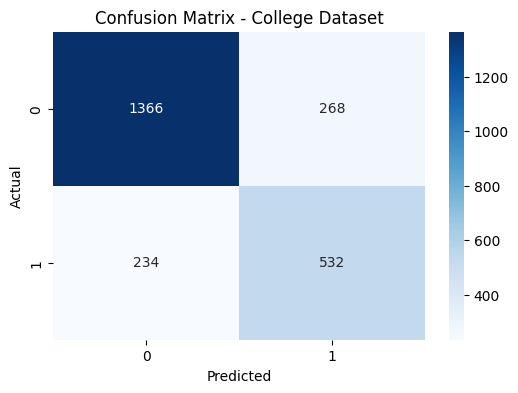

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - College Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()